# Dataset propio: detección de enfermedad hepática (HCV Data)

## Pregunta
¿Puede una SVM identificar pacientes con enfermedad hepática (hepatitis C, fibrosis o cirrosis) a partir de una analítica sanguínea de rutina, para priorizarlos para revisión?

## Unidad de análisis
Un paciente o donante de sangre, con una analítica sanguínea y sus datos de edad y sexo.

## Target
`hepatopatia` (derivado de `Category`): `si` = hepatitis, fibrosis o cirrosis; `no` = donante sano.

## Fuente
UCI ML Repository, *HCV Data* (CC BY 4.0, DOI 10.24432/C5D612). La procedencia está en `docs/ficha_dataset.md` y el diccionario en `docs/diccionario_datos.md`.

## Advertencia
Ejercicio académico. Los resultados **no constituyen un diagnóstico médico**.

> **Estado:** los resultados de este notebook son preliminares hasta que el docente apruebe el dataset.

In [11]:
# VS Code ejecuta el notebook desde notebooks/; se trabaja desde la raíz del proyecto
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
print(Path.cwd())

c:\Users\roque.ventura\Desktop\Desktop\Maestria UASD\Materias\Ciencia de datos II\INF8239_U01


## 1. Descarga reproducible

In [12]:
from src.inf8239_u01.data import download_csv
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00571/hcvdat0.csv"
path = download_csv(URL)
print(path)

data\raw\dataset.csv


## 2. Esquema

In [13]:
import pandas as pd
df = pd.read_csv("data/raw/dataset.csv")
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.tail())
assert not df.empty

(615, 14)
Unnamed: 0      int64
Category       object
Age             int64
Sex            object
ALB           float64
ALP           float64
ALT           float64
AST           float64
BIL           float64
CHE           float64
CHOL          float64
CREA          float64
GGT           float64
PROT          float64
dtype: object
   Unnamed: 0       Category  Age Sex   ALB   ALP   ALT   AST   BIL    CHE  \
0           1  0=Blood Donor   32   m  38.5  52.5   7.7  22.1   7.5   6.93   
1           2  0=Blood Donor   32   m  38.5  70.3  18.0  24.7   3.9  11.17   
2           3  0=Blood Donor   32   m  46.9  74.7  36.2  52.6   6.1   8.84   
3           4  0=Blood Donor   32   m  43.2  52.0  30.6  22.6  18.9   7.33   
4           5  0=Blood Donor   32   m  39.2  74.1  32.6  24.8   9.6   9.15   

   CHOL   CREA   GGT  PROT  
0  3.23  106.0  12.1  69.0  
1  4.80   74.0  15.6  76.5  
2  5.20   86.0  33.2  79.3  
3  4.74   80.0  33.8  75.7  
4  4.32   76.0  29.9  68.7  
     Unnamed: 0     Categ

## 3. Auditoría

In [14]:
audit = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "ausentes": df.isna().sum(),
    "porcentaje_ausente": (df.isna().mean()*100).round(2),
    "unicos": df.nunique(dropna=False)
}).sort_values("porcentaje_ausente", ascending=False)
print("Duplicados:", df.duplicated().sum())
display(audit)

Duplicados: 0


,tipo,ausentes,porcentaje_ausente,unicos
ALP,float64,18,2.93,415
CHOL,float64,10,1.63,314
ALT,float64,1,0.16,342
PROT,float64,1,0.16,199
ALB,float64,1,0.16,190
Category,object,0,0.00,5
Age,int64,0,0.00,49
Sex,object,0,0.00,2
Unnamed: 0,int64,0,0.00,615
AST,float64,0,0.00,297


In [15]:
# ¿Los ausentes y el identificador están relacionados con la clase?
print(df["Category"].value_counts())
print("\nFilas con algún ausente, por clase:")
print(df[df.isna().any(axis=1)]["Category"].value_counts())
print("\nRango del identificador por clase:")
print(df.groupby("Category")["Unnamed: 0"].agg(["min", "max"]))

Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64

Filas con algún ausente, por clase:
Category
2=Fibrosis       9
0=Blood Donor    7
3=Cirrhosis      6
1=Hepatitis      4
Name: count, dtype: int64

Rango del identificador por clase:
                        min  max
Category                        
0=Blood Donor             1  533
0s=suspect Blood Donor  534  540
1=Hepatitis             541  564
2=Fibrosis              565  585
3=Cirrhosis             586  615


### Resultado de la auditoría

- 615 filas y 14 columnas: 12 predictores (10 continuos, `Age` entera y `Sex` categórica), el identificador `Unnamed: 0` y el target `Category`. No hay filas duplicadas.
- Hay 31 celdas ausentes en 26 filas, sobre todo en `ALP` (2.9 %) y `CHOL` (1.6 %). Se concentran en pacientes enfermos, así que la ausencia es informativa. Se imputan con la mediana **dentro del pipeline**, para que la imputación solo aprenda del conjunto de entrenamiento.
- **El identificador está ordenado por clase**: los donantes ocupan las filas 1-533 y los enfermos las 541-615. Si entrara en el modelo sería una fuga perfecta.
- El desbalance es fuerte: 533 donantes frente a 75 enfermos.
- El significado, la unidad, la fuente, la disponibilidad, la transformación y el riesgo de cada variable están en `docs/diccionario_datos.md`.

## 4. Target y exclusiones

In [16]:
# 0s = "suspect Blood Donor": la etiqueta es incierta (ni sano ni enfermo confirmado), así que se excluye
df = df[df["Category"] != "0s=suspect Blood Donor"].copy()
df["hepatopatia"] = df["Category"].str[0].map({"0": "no", "1": "si", "2": "si", "3": "si"})
print(df.shape)

(608, 15)


In [17]:
TARGET = "hepatopatia"
DROP_COLUMNS = ["Unnamed: 0", "Category"]  # identificador con fuga y fuente del target
assert TARGET in df.columns
X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]
print(y.value_counts(dropna=False))
assert y.notna().all()
assert y.nunique() >= 2

hepatopatia
no    533
si     75
Name: count, dtype: int64


### Justificación de las exclusiones

| Exclusión | Razón |
|---|---|
| 7 filas `0s=suspect Blood Donor` | Semántica: su etiqueta es incierta y no sirven ni como positivo ni como negativo fiable. |
| `Unnamed: 0` | Es un identificador sin significado clínico y está ordenado por clase (fuga). |
| `Category` | Es la fuente del target; incluirla sería usar la respuesta como predictor. |

Ninguna columna se elimina por su efecto en la métrica. Todas las analíticas se obtienen antes del diagnóstico, así que están disponibles al momento de predecir.

## 5. Preprocesamiento dentro de Pipeline

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([("num", num_pipe, num_cols),
                                ("cat", cat_pipe, cat_cols)])
print(len(num_cols), len(cat_cols))

11 1


## 6. Partición, línea base y SVM

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score

Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.20,random_state=42,stratify=y)
dummy=Pipeline([("prep",preprocess),("model",DummyClassifier(strategy="most_frequent"))])
svm=Pipeline([("prep",preprocess),("model",SVC(C=1,gamma="scale",probability=True,random_state=42))])
for name,model in {"dummy":dummy,"svm":svm}.items():
    model.fit(Xtr,ytr)
    pred=model.predict(Xte)
    print(name, f1_score(yte,pred,average="macro"))
print(classification_report(yte,svm.predict(Xte)))

dummy

 0.4672489082969432
svm 0.8440182648401826
              precision    recall  f1-score   support

          no       0.95      0.99      0.97       107
          si       0.90      0.60      0.72        15

    accuracy                           0.94       122
   macro avg       0.92      0.80      0.84       122
weighted avg       0.94      0.94      0.94       122



[[106   1]
 [  6   9]]
Enfermos clasificados como sanos (FN): 6
Sanos clasificados como enfermos (FP): 1


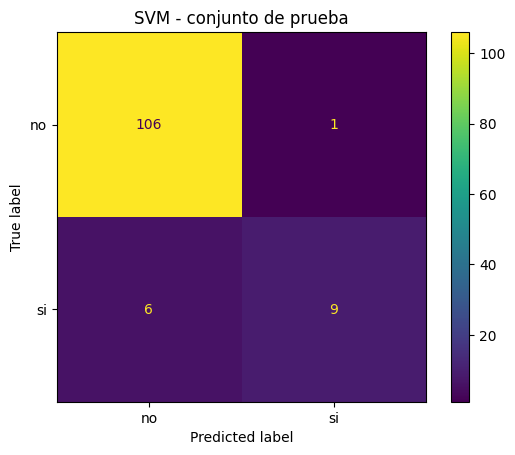

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

svm_pred = svm.predict(Xte)
cm = confusion_matrix(yte, svm_pred, labels=["no", "si"])
print(cm)
print("Enfermos clasificados como sanos (FN):", cm[1, 0])
print("Sanos clasificados como enfermos (FP):", cm[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["no", "si"]).plot()
plt.title("SVM - conjunto de prueba")
plt.show()

### Interpretación

- **Línea base:** F1-macro de 0.467. Siempre predice `no`, así que no detecta a ningún enfermo.
- **SVM (C=1, gamma="scale"):** F1-macro de 0.844, con la misma partición y el mismo preprocesamiento. Supera claramente la línea base.
- **Matriz de confusión:** de 15 enfermos en prueba, la SVM detecta 9 y **pasa por alto 6** (recall de `si` = 0.60). Solo produce 1 falsa alarma entre 107 donantes. El error que más comete es justamente el más costoso: el falso negativo.
- **Siguiente paso** (tras la aprobación y en el Ejercicio 01): ajustar `class_weight="balanced"`, C y gamma mediante `GridSearchCV` con validación cruzada estratificada sobre el conjunto de entrenamiento, y valorar el recall de `si` junto al F1-macro.

La conclusión completa está en `reports/conclusion_lab02.md`.